<a href="https://colab.research.google.com/github/ThiagoMedeiros12/ENEM-MACHINE-LEARNING/blob/main/ENEM_MACHINE_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import plotly.graph_objects as go
from google.colab import drive

drive.mount('/content/drive',force_remount=True)
FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/DADOS_TREINAMENTOS_NORMALIZADO.csv"
CHUNK_SIZE = 500000

DF = pd.read_csv(FILE_PATH, sep=';', low_memory=False,nrows=CHUNK_SIZE)
print(DF.columns.tolist())

Mounted at /content/drive
['NU_INSCRICAO', 'NU_ANO', 'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU', 'TP_ENSINO', 'Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'TP_LINGUA', 'TP_STATUS_REDACAO', 'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4', 'NU_NOTA_COMP5', 'NU_NOTA_REDACAO', 'CO_UF_PROVA', 'MEDIA_PROVAS', 'Class_Nota_Redação', 'Class_Nota_Prova']


Classificamos então as notas seguindo os parametros onde as notas iguais ou inferiores a 450 são consideradas -1 = Nota baixa, Superiores a 450 e inferiores a 450 e iguais ou inferiores a 650 serão consideradas 0 = nota média e acima de 650 serão consideradas 1 = Notas altas

#Redação:

In [ ]:
import pandas as pd
import numpy as np
import os
import logging

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

def classificar_notas(file_path, output_path):
    logging.info(f"Lendo o arquivo: {file_path} em chunks e classificando...")

    try:
        chunksize = 100_000
        first_chunk = True

        for chunk in pd.read_csv(file_path, sep=';', low_memory=False, chunksize=chunksize):
            condicoes = [
                (chunk['NU_NOTA_REDACAO'] <= 450),
                (chunk['NU_NOTA_REDACAO'] > 450) & (chunk['NU_NOTA_REDACAO'] <= 650),
                (chunk['NU_NOTA_REDACAO'] > 650)
            ]

            valores = [-1, 0, 1]

            chunk['Class_Nota_Redação'] = np.select(condicoes, valores, default=pd.NA)

            mode = 'w' if first_chunk else 'a'
            header = first_chunk

            chunk.to_csv(output_path, sep=';', index=False, mode=mode, header=header)
            first_chunk = False

        logging.info(f"Salvo com sucesso em: {output_path}")

    except Exception as e:
        logging.error(f"Erro durante o processamento: {e}")
        raise

if __name__ == "__main__":
    entrada = os.path.join(DADOS_BASE)
    saida = os.path.join('/content/drive/MyDrive/Colab Notebooks/', 'dados_SP_CO_UF_35_classificados.csv')
    classificar_notas(entrada, saida)




#NOTA MÉDIA:

In [ ]:
import pandas as pd
import numpy as np
import os
import logging

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

def classificar_notas(file_path, output_path):
    logging.info(f"Lendo o arquivo: {file_path} em chunks e classificando...")

    try:
        chunksize = 100_000
        first_chunk = True

        for chunk in pd.read_csv(file_path, sep=';', low_memory=False, chunksize=chunksize):
            condicoes = [
                (chunk['MEDIA_PROVAS'] <= 450),
                (chunk['MEDIA_PROVAS'] > 450) & (chunk['MEDIA_PROVAS'] <= 650),
                (chunk['MEDIA_PROVAS'] > 650)
            ]

            valores = [-1, 0, 1]

            chunk['Class_Nota_Prova'] = np.select(condicoes, valores, default=pd.NA)

            mode = 'w' if first_chunk else 'a'
            header = first_chunk

            chunk.to_csv(output_path, sep=';', index=False, mode=mode, header=header)
            first_chunk = False

        logging.info(f"Salvo com sucesso em: {output_path}")

    except Exception as e:
        logging.error(f"Erro durante o processamento: {e}")
        raise

if __name__ == "__main__":
    entrada = os.path.join(DADOS_BASE_CLASSIFICADOS)
    saida = os.path.join('/content/drive/MyDrive/Colab Notebooks/', 'dados_SP_CO_UF_35_classificado.csv')
    classificar_notas(entrada, saida)




#Script para normalização de valores na base:


In [ ]:
import pandas as pd
import numpy as np
import os
import logging
from google.colab import drive
drive.mount('/content/drive',force_remount=True)
DADOS_BASE_CLASSIFICADO = "/content/drive/MyDrive/Colab Notebooks/dados_SP_CO_UF_35_classificado.csv"


logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

# ==============================================================================
# CONFIGURAÇÕES DA NORMALIZAÇÃO
# ==============================================================================
# Arquivo de entrada e saída
INPUT_FILE = DADOS_BASE_CLASSIFICADO
OUTPUT_FILE = os.path.join('/content/drive/MyDrive/Colab Notebooks/', 'dados_SP_CO_UF_35_classificados.csv')

# Coluna que será normalizada
TARGET_COLUMN = 'NOME_DA_COLUNA'

# Exemplo 1: Regras usando Dicionário (Substituição direta)
# Útil para mapear valores (ex: 'Feminino' -> 1, 'Masculino' -> 2)
MAPPING_RULES = {

}

def apply_normalization_rules(df):
    """
    Função principal onde a normalização acontece.
    """

    # --------------------------------------------------------------------------
    # ESTRATÉGIA: Mapeamento Direto por Dicionário
    # --------------------------------------------------------------------------
    # Substitui os valores antigos pelos novos baseados no MAPPING_RULES acima.
    df[TARGET_COLUMN] = df[TARGET_COLUMN].replace(MAPPING_RULES)

    return df

# ==============================================================================
# SCRIPT DE EXECUÇÃO
# ==============================================================================
def run_normalization():
    logging.info(f"Iniciando a leitura e normalização em chunks: {INPUT_FILE}")

    try:
        chunksize = 100_000
        first_chunk = True

        # Lê o CSV original em pedaços para suportar arquivos gigantes
        for chunk in pd.read_csv(INPUT_FILE, sep=';', low_memory=False, chunksize=chunksize):

            # Verifica se a coluna alvo existe antes de tentar aplicar regras nela
            if TARGET_COLUMN in chunk.columns:
                chunk = apply_normalization_rules(chunk)
            else:
                logging.warning(f"A coluna '{TARGET_COLUMN}' não foi encontrada na base de dados!")
                break # Para a execução se a coluna não existe

            # Salva o chunk no arquivo de saída
            mode = 'w' if first_chunk else 'a'
            header = first_chunk

            chunk.to_csv(OUTPUT_FILE, sep=';', index=False, mode=mode, header=header)
            first_chunk = False

        logging.info(f"Processo concluído com sucesso. Base salva em: {OUTPUT_FILE}")

    except FileNotFoundError:
        logging.error(f"O arquivo {INPUT_FILE} não foi encontrado.")
    except Exception as e:
        logging.error(f"Erro inesperado durante o processamento: {e}")
        raise

if __name__ == "__main__":
    run_normalization()


Script para excluir o ano de 2014,2023,2024
 # Não Utilizar !! #

In [ ]:
import pandas as pd
import numpy as np
import os
import logging
from google.colab import drive
drive.mount('/content/drive',force_remount=True)
DADOS_BASE_CLASSIFICADO = "/content/drive/MyDrive/Colab Notebooks/DADOS_TREINAMENTO.csv"
DADOS_BASE_FINAL = "/content/drive/MyDrive/Colab Notebooks/DADOS_TREINAMENTOS.csv"
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
# ==============================================================================
# CONFIGURAÇÕES DA NORMALIZAÇÃO
# ==============================================================================
# Arquivo de entrada e saída
INPUT_FILE = DADOS_BASE_CLASSIFICADO
OUTPUT_FILE = DADOS_BASE_FINAL
# Coluna alvo para o filtro
TARGET_COLUMN = 'NU_ANO'
def apply_normalization_rules(df):
    """
    Função principal onde a normalização e os filtros acontecem.
    """

    # --------------------------------------------------------------------------
    # ESTRATÉGIA: Filtragem de Linhas
    # --------------------------------------------------------------------------
    # Remove todas as linhas onde o valor da coluna é 2014 (como número ou string)
    df = df[~df[TARGET_COLUMN].isin([2024,2023, '2024','2023'])]
    return df
# ==============================================================================
# SCRIPT DE EXECUÇÃO
# ==============================================================================
def run_normalization():
    logging.info(f"Iniciando a leitura e normalização em chunks: {INPUT_FILE}")

    try:
        chunksize = 100_000
        first_chunk = True

        # Lê o CSV original em pedaços para suportar arquivos gigantes
        for chunk in pd.read_csv(INPUT_FILE, sep=';', low_memory=False, chunksize=chunksize):

            # Verifica se a coluna alvo existe antes de tentar aplicar regras nela
            if TARGET_COLUMN in chunk.columns:
                chunk = apply_normalization_rules(chunk)
            else:
                logging.warning(f"A coluna '{TARGET_COLUMN}' não foi encontrada na base de dados!")
                break # Para a execução se a coluna não existe

            # Salva o chunk no arquivo de saída
            mode = 'w' if first_chunk else 'a'
            header = first_chunk

            chunk.to_csv(OUTPUT_FILE, sep=';', index=False, mode=mode, header=header)
            first_chunk = False

        logging.info(f"Processo concluído com sucesso. Base salva em: {OUTPUT_FILE}")

    except FileNotFoundError:
        logging.error(f"O arquivo {INPUT_FILE} não foi encontrado.")
    except Exception as e:
        logging.error(f"Erro inesperado durante o processamento: {e}")
        raise
if __name__ == "__main__":
    run_normalization()


Mounted at /content/drive


Consultar valores unicos nas colunas da base :

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from google.colab import drive
drive.mount('/content/drive',force_remount=True)
DADOS_BASE_CLASSIFICADO = "/content/drive/MyDrive/Colab Notebooks/DADOS_TREINAMENTOS_NORMALIZADO.csv"

CHUNK_SIZE = 500000
FILE_PATH = DADOS_BASE_CLASSIFICADO



Columns_select = ['Q001']  # Adicione aqui as colunas que deseja analisar
def main():
    print(f"Lendo o arquivo {FILE_PATH} em partes (chunks)...")
    counts_dict = {}

    try:
        # Lê o CSV em partes para evitar estouro de memória, selecionando apenas as colunas desejadas
        for chunk in pd.read_csv(FILE_PATH, sep=';', encoding='utf-8', chunksize=CHUNK_SIZE, usecols=Columns_select):
            for col in chunk.columns:
                # Calcula a frequência dos valores únicos na coluna
                col_counts = chunk[col].value_counts(dropna=False)
                if col not in counts_dict:
                    counts_dict[col] = col_counts
                else:
                    counts_dict[col] = counts_dict[col].add(col_counts, fill_value=0)

    except Exception as e:
        print(f"Erro ao ler o arquivo: {e}")
        return

    print("Gerando e plotando tabelas...")
    for col, counts in counts_dict.items():
        # Converte para inteiro, ordena e reseta o index
        counts = counts.astype(int).sort_values(ascending=False)
        df_counts = counts.reset_index()
        df_counts.columns = ['Valores Únicos', 'Número de Linhas']

        # Converte para string para garantir a exibição correta na tabela (Plotly)
        df_counts['Valores Únicos'] = df_counts['Valores Únicos'].astype(str)

        # Cria a tabela usando Plotly
        fig = go.Figure(data=[go.Table(
            header=dict(values=list(df_counts.columns),
                        fill_color='paleturquoise',
                        align='left',
                        font=dict(size=14, color='black')),
            cells=dict(values=[df_counts['Valores Únicos'], df_counts['Número de Linhas']],
                       fill_color='lavender',
                       align='left',
                       font=dict(size=12, color='black')))
        ])
        fig.update_layout(title=f'Frequência de valores - Coluna: {col}')

        # Plota a tabela
        fig.show()

if __name__ == "__main__":
    main()


Criação de tabelas de curva normal:

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from google.colab import drive
from collections import defaultdict

# 1. Monta o Google Drive
drive.mount('/content/drive', force_remount=True)
FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/DADOS_TREINAMENTOS.csv"
CHUNK_SIZE = 500000

# 2. Configurações do Gráfico
SCORE_COLUMN = 'MEDIA_PROVAS'       # A coluna de Notas (Variável Contínua)
CATEGORICAL_COLUMN = 'Q022'     # A coluna que possui os "valores únicos" (ex: Ano, Sexo, Renda)

def main():
    print(f"Lendo o arquivo {FILE_PATH} em partes (chunks)...")

    dados_por_categoria = defaultdict(list)
    colunas_para_ler = [SCORE_COLUMN, CATEGORICAL_COLUMN]

    try:
        for chunk in pd.read_csv(FILE_PATH, sep=';', encoding='utf-8', chunksize=CHUNK_SIZE, usecols=colunas_para_ler):
            chunk_limpo = chunk.dropna(subset=[SCORE_COLUMN])

            for categoria, grupo in chunk_limpo.groupby(CATEGORICAL_COLUMN):
                dados_por_categoria[categoria].append(grupo[SCORE_COLUMN])

    except Exception as e:
        print(f"Erro ao ler o arquivo: {e}")
        return

    print("Gerando Curvas Normais (Gráficos Separados)...")

    cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

    for i, (categoria, listas_de_series) in enumerate(dados_por_categoria.items()):
        if not listas_de_series:
            continue

        serie = pd.concat(listas_de_series, ignore_index=True)

        mu = serie.mean()
        sigma = serie.std()
        min_val = serie.min()
        max_val = serie.max()

        x_curve = np.linspace(min_val, max_val, 500)
        bin_size = 10 if max_val > 100 else (max_val - min_val) / 50
        xbins = dict(start=min_val, end=max_val, size=bin_size)

        N = len(serie)
        if sigma > 0:
            y_density = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_curve - mu) / sigma) ** 2)
            y_counts = y_density * N * bin_size
        else:
            y_counts = np.zeros_like(x_curve)

        cor = cores[i % len(cores)]

        # Cria um novo gráfico para ESTA categoria
        fig = go.Figure()

        fig.add_trace(go.Histogram(
            x=serie,
            name=f'Distribuição Real',
            marker_color=cor,
            opacity=0.4,
            xbins=xbins
        ))

        fig.add_trace(go.Scatter(
            x=x_curve,
            y=y_counts,
            mode='lines',
            name=f'Curva Normal | N={N} | Média={mu:.2f}',
            line=dict(color='black', width=3) # A linha fica sempre preta/escura para contraste
        ))

        fig.update_layout(
            title_text=f'Curva Normal: {SCORE_COLUMN} - {CATEGORICAL_COLUMN}: {categoria}',
            yaxis_title='Quantidade de Pessoas',
            xaxis_title='Notas',
            template='plotly_white',
            barmode='overlay'
        )

        fig.show()

if __name__ == "__main__":
    main()

Mounted at /content/drive
Lendo o arquivo /content/drive/MyDrive/Colab Notebooks/DADOS_TREINAMENTOS_NORMALIZADO.csv em chunks...


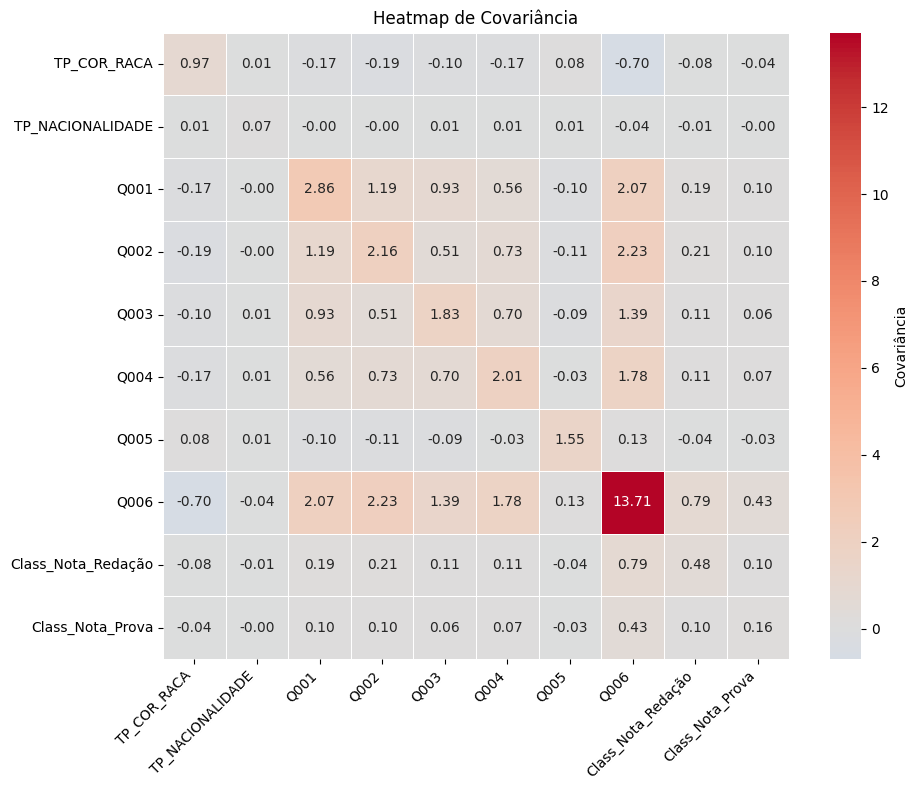


Matriz de Covariância:
                    TP_COR_RACA  TP_NACIONALIDADE      Q001      Q002  \
TP_COR_RACA            0.968794          0.014126 -0.174647 -0.193103   
TP_NACIONALIDADE       0.014126          0.073250 -0.001224 -0.003010   
Q001                  -0.174647         -0.001224  2.864235  1.186891   
Q002                  -0.193103         -0.003010  1.186891  2.163485   
Q003                  -0.098226          0.006062  0.926248  0.510849   
Q004                  -0.165858          0.005968  0.557607  0.731214   
Q005                   0.077722          0.007696 -0.098816 -0.108410   
Q006                  -0.699608         -0.036329  2.070709  2.226051   
Class_Nota_Redação    -0.080038         -0.008933  0.193572  0.208839   
Class_Nota_Prova      -0.042759         -0.004903  0.096519  0.098466   

                        Q003      Q004      Q005       Q006  \
TP_COR_RACA        -0.098226 -0.165858  0.077722  -0.699608   
TP_NACIONALIDADE    0.006062  0.005968  0.0076

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
import pandas as pd
import logging as lg
import numpy as np

drive.mount('/content/drive', force_remount=True)

FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/DADOS_TREINAMENTOS_NORMALIZADO.csv"
CHUNK_SIZE = 500000
MAX_ROWS = 10000
MAX_TOTAL_COLS = 10

# Obrigatórias
COLUNAS_OBRIGATORIAS = ["Class_Nota_Redação", "Class_Nota_Prova"]

# Extras (máx. 8, porque 2 já são obrigatórias)
COLUNAS_EXTRAS = [
    "Q001", "Q002", "Q003", "Q004", "Q005", "Q006",
    #"TP_SEXO", "TP_ESTADO_CIVIL"
    "TP_COR_RACA",
    "TP_NACIONALIDADE",
]

lg.basicConfig(level=lg.INFO, format="%(levelname)s: %(message)s")


def main():
    if len(COLUNAS_EXTRAS) > (MAX_TOTAL_COLS - len(COLUNAS_OBRIGATORIAS)):
        raise ValueError("Você pode selecionar no máximo 8 colunas extras (total 10 com as obrigatórias).")

    # Junta obrigatórias + extras e remove duplicadas mantendo ordem
    COLUNAS_ANALISE = list(dict.fromkeys(COLUNAS_OBRIGATORIAS + COLUNAS_EXTRAS))

    print(f"Lendo o arquivo {FILE_PATH} em chunks...")
    chunks = []

    try:
        for chunk in pd.read_csv(
            FILE_PATH,
            sep=";",
            encoding="utf-8",
            usecols=COLUNAS_ANALISE,
            chunksize=CHUNK_SIZE
        ):
            chunks.append(chunk)
    except Exception as e:
        print(f"Erro ao ler o arquivo: {e}")
        return

    if not chunks:
        print("Nenhum dado carregado.")
        return

    data = pd.concat(chunks, ignore_index=True)

    # Converte categóricas para códigos numéricos
    for c in data.columns:
        if not pd.api.types.is_numeric_dtype(data[c]):
            data[c] = data[c].astype("category").cat.codes.replace(-1, np.nan)

    data = data.dropna()

    if data.empty:
        print("Sem dados válidos após limpeza/conversão.")
        return

    if len(data) > MAX_ROWS:
        data = data.sample(n=MAX_ROWS, random_state=42)

    cov = data.cov()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cov,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "Covariância"},
    )
    plt.title("Heatmap de Covariância")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("\nMatriz de Covariância:")
    print(cov)


if __name__ == "__main__":
    main()

Mounted at /content/drive
Lendo o arquivo /content/drive/MyDrive/Colab Notebooks/DADOS_TREINAMENTOS_NORMALIZADO.csv em chunks...


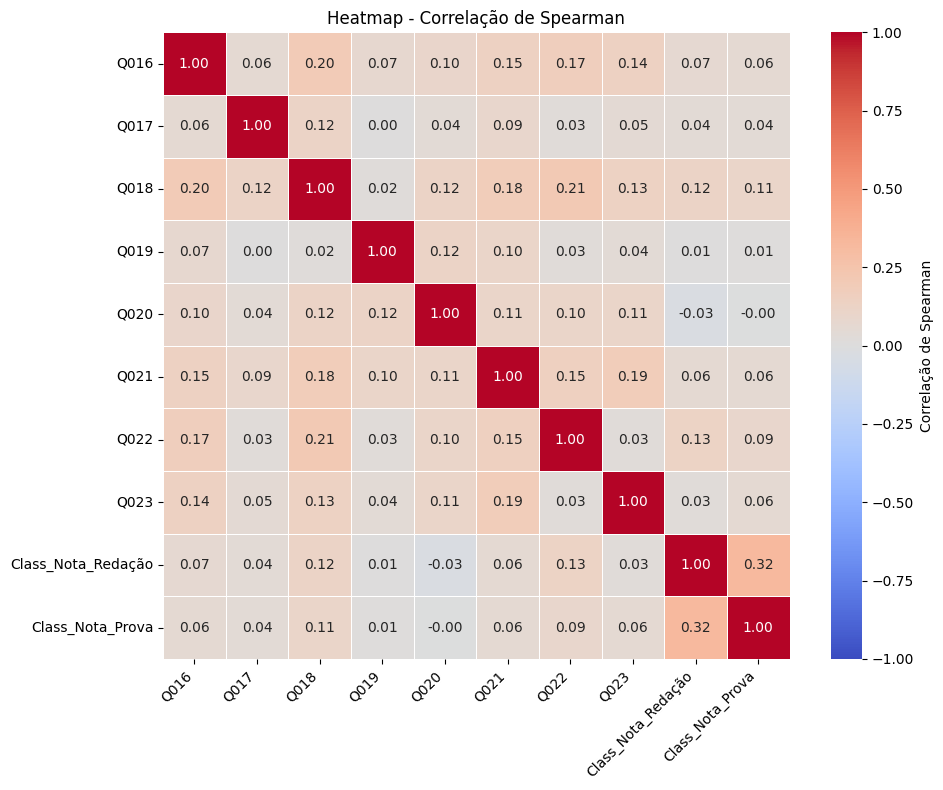


Matriz de Correlação de Spearman:
                        Q016      Q017      Q018      Q019      Q020  \
Q016                1.000000  0.059829  0.200946  0.073149  0.099301   
Q017                0.059829  1.000000  0.121405  0.004632  0.044804   
Q018                0.200946  0.121405  1.000000  0.020831  0.117323   
Q019                0.073149  0.004632  0.020831  1.000000  0.118808   
Q020                0.099301  0.044804  0.117323  0.118808  1.000000   
Q021                0.145738  0.090402  0.184128  0.101619  0.108464   
Q022                0.166498  0.028998  0.213184  0.031188  0.103458   
Q023                0.142423  0.048607  0.133559  0.042664  0.107432   
Class_Nota_Redação  0.066515  0.043719  0.124765  0.005451 -0.028869   
Class_Nota_Prova    0.057739  0.042197  0.106650  0.011173 -0.003420   

                        Q021      Q022      Q023  Class_Nota_Redação  \
Q016                0.145738  0.166498  0.142423            0.066515   
Q017                0.090402

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
import pandas as pd
import logging as lg
import numpy as np
import unicodedata

drive.mount('/content/drive', force_remount=True)

FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/DADOS_TREINAMENTOS_NORMALIZADO.csv"
CHUNK_SIZE = 500000
MAX_ROWS = 2500000
MAX_TOTAL_COLS = 10

# Sempre entram na análise
COLUNAS_OBRIGATORIAS = ["Class_Nota_Redação", "Class_Nota_Prova"]

# Escolha aqui as extras (máx. 8, porque 2 já são obrigatórias)
COLUNAS_EXTRAS = [
    #"Q001",
    #"Q002",
    #"Q003",
    #"Q004",
    #"Q005",
    #"Q006",
    #"TP_COR_RACA",
    #"TP_NACIONALIDADE",
    #'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014'
    #'Q014', 'Q015',
    'Q016', 'Q017', 'Q018', 'Q019', 'Q020', 'Q021', 'Q022', 'Q023'
]

lg.basicConfig(level=lg.INFO, format="%(levelname)s: %(message)s")


def norm_col(s):
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s


def main():
    max_extras = MAX_TOTAL_COLS - len(COLUNAS_OBRIGATORIAS)
    if len(COLUNAS_EXTRAS) > max_extras:
        raise ValueError(
            f"Você pode escolher no máximo {max_extras} colunas extras "
            f"(total máximo {MAX_TOTAL_COLS} com as obrigatórias)."
        )

    colunas_pedidas = list(dict.fromkeys(COLUNAS_OBRIGATORIAS + COLUNAS_EXTRAS))

    # Lê apenas cabeçalho para mapear nomes com/sem acento
    header = pd.read_csv(FILE_PATH, sep=";", encoding="utf-8", nrows=0)
    mapa_csv = {norm_col(c): c for c in header.columns}

    colunas_resolvidas = []
    faltantes = []
    for c in colunas_pedidas:
        key = norm_col(c)
        if key in mapa_csv:
            colunas_resolvidas.append(mapa_csv[key])
        else:
            faltantes.append(c)

    if faltantes:
        raise ValueError(f"Estas colunas não foram encontradas no CSV: {faltantes}")

    print(f"Lendo o arquivo {FILE_PATH} em chunks...")
    chunks = []
    try:
        for chunk in pd.read_csv(
            FILE_PATH,
            sep=";",
            encoding="utf-8",
            usecols=colunas_resolvidas,
            chunksize=CHUNK_SIZE,
        ):
            chunks.append(chunk)
    except Exception as e:
        print(f"Erro ao ler o arquivo: {e}")
        return

    if not chunks:
        print("Nenhum dado carregado.")
        return

    data = pd.concat(chunks, ignore_index=True)

    # Converte para numérico:
    # - se a coluna já for quase toda numérica, mantém numérica
    # - senão, codifica categorias em inteiros
    for c in data.columns:
        num = pd.to_numeric(data[c], errors="coerce")
        if num.notna().mean() >= 0.95:
            data[c] = num
        else:
            codes, _ = pd.factorize(data[c], sort=True)
            data[c] = pd.Series(codes, index=data.index).replace(-1, np.nan)

    data = data.dropna()

    if data.empty:
        print("Sem dados válidos após limpeza/conversão.")
        return

    if len(data) > MAX_ROWS:
        data = data.sample(n=MAX_ROWS, random_state=42)

    # CORRELAÇÃO DE SPEARMAN
    corr_spearman = data.corr(method="spearman")

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_spearman,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "Correlação de Spearman"},
    )
    plt.title("Heatmap - Correlação de Spearman")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("\nMatriz de Correlação de Spearman:")
    print(corr_spearman)


if __name__ == "__main__":
    main()

# Tratamento da Base #

### Dicionário de Variaveis ###




# Dicionário de Variáveis

| Variável | Descrição | Valores | Descrição |
|---|---|---|---|
| `TP_SEXO` | Sexo do participante | { 'M': 0, 'F': 1} |
| `TP_ESTADO_CIVIL` | Estado civil do participante |{ 0: 0, 1: 1, 2: 2, 3: 3, 4: 4} |
| `TP_COR_RACA` | Cor/Raça autodeclarada |{ 0: 0, 1: 1, 2: 2, 3: 3, 4: 4,     5: 5, 6: 6} |
| `TP_NACIONALIDADE` | Nacionalidade do participante |{ 0: 0, 1: 1, 2: 2,      3: 3, 4: 4}|
| `TP_ST_CONCLUSAO` | Situação de conclusão do Ensino Médio |{ 0: 0, 1: 1, 2: 2, 3: 3, 4: 4}|
| `Q001` | Escolaridade do pai |{ 'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7}| {A - Nunca estudou.; B - Não completou a 4ª série/5º ano do Ensino Fundamental.; C - Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.; D - Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.; E - Completou o Ensino Médio, mas não completou a Faculdade.; F - Completou a Faculdade, mas não completou a Pós-graduação.; G - Completou a Pós-graduação.; H - Não sei.}|
| `Q002` | Escolaridade da mãe |{ 'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7}|{A - Nunca estudou.; B - Não completou a 4ª série/5º ano do Ensino Fundamental.; C - Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.; D - Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.; E - Completou o Ensino Médio, mas não completou a Faculdade.; F - Completou a Faculdade, mas não completou a Pós-graduação.; G - Completou a Pós-graduação.; H - Não sei. }|
| `Q003` | Ocupação do pai |{ 'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}|{A - Grupo 1: Lavrador, agricultor sem empregados, bóia fria, criador de animais, apicultor, pescador, lenhador, seringueiro, extrativista.; B - Grupo 2: Diarista, empregado doméstico, cuidador de idosos, babá, cozinheiro, motorista particular, jardineiro, faxineiro, vigilante, porteiro, carteiro, office-boy, vendedor, caixa, atendente de loja, auxiliar administrativo, recepcionista, servente de pedreiro, repositor de mercadoria.; C - Grupo 3: Padeiro, cozinheiro industrial, sapateiro, costureiro, joalheiro, torneiro mecânico, operador de máquinas, soldador, operário de fábrica, trabalhador da mineração, pedreiro, pintor, eletricista, encanador, motorista, caminhoneiro, taxista.; D - Grupo 4: Professor, técnico, policial, militar, corretor de imóveis, supervisor, gerente, mestre de obras, pastor, microempresário, pequeno comerciante, pequeno proprietário de terras, trabalhador autônomo.; E - Grupo 5: Médico, engenheiro, dentista, psicólogo, economista, advogado, juiz, promotor, defensor, delegado, tenente, capitão, coronel, professor universitário, diretor, político, proprietário de empresas com mais de 10 empregados.; F - Não sei.}|
| `Q004` | Ocupação da mãe |{ 'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}| {A - Grupo 1: Lavradora, agricultora sem empregados, bóia fria, criadora de animais, apicultora, pescadora, lenhadora, seringueira, extrativista.; B - Grupo 2: Diarista, empregada doméstica, cuidadora de idosos, babá, cozinheira, motorista particular, jardineira, faxineira, vigilante, porteira, carteira, office-boy, vendedora, caixa, atendente de loja, auxiliar administrativa, recepcionista, servente de pedreiro, repositora de mercadoria.; C - Grupo 3: Padeira, cozinheira industrial, sapateira, costureira, joalheira, torneira mecânica, operadora de máquinas, soldadora, operária de fábrica, trabalhadora da mineração, pedreira, pintora, eletricista, encanadora, motorista, caminhoneira, taxista.; D - Grupo 4: Professora, técnica, policial, militar, corretora de imóveis, supervisora, gerente, mestre de obras, pastora, microempresária, pequena comerciante, pequena proprietária de terras, trabalhadora autônoma.; E - Grupo 5: Médica, engenheira, dentista, psicóloga, economista, advogada, juíza, promotora, defensora, delegada, tenente, capitã, coronel, professora universitária, diretora, política, proprietária de empresas com mais de 10 empregados.; F - Não sei. }|
| `Q005` | Número de pessoas na residência |{ 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20}| {Quantidade}|
| `Q006` | Faixa de renda familiar mensal |{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16}|A - Nenhuma renda.; B - Até 1.045,00.; C - De 1.045,01 até 1.567,50.; D - De 1.567,51 até 2.090,00.; E - De 2.090,01 até 2.612,50.; F - De 2.612,51 até 3.135,00.; G - De 3.135,01 até 4.180,00.; H - De 4.180,01 até 5.225,00.; I - De 5.225,01 até 6.270,00.; J - De 6.270,01 até 7.315,00.; K - De 7.315,01 até 8.360,00.; L - De 8.360,01 até 9.405,00.; M - De 9.405,01 até 10.450,00.; N - De 10.450,01 até 12.540,00.; O - De 12.540,01 até 15.675,00.; P - De 15.675,01 até 20.900,00.; Q - Acima de 20.900,00. |
| `Q007` | Indicador de presença de empregada doméstica na residência |{'A': 0, 'B': 1, 'C': 2, 'D': 3}|{A - Não.; B - Sim, um ou dois dias por semana.; C - Sim, três ou quatro dias por semana.; D - Sim, pelo menos cinco dias por semana. }|
| `Q008` | Quantidade de banheiros na residência |{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}|{A - Não.; B - Sim, um.; C - Sim, dois.; D - Sim, três.; E - Sim, quatro ou mais. }|
| `Q009` | Quantidade de quartos na residência |{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}|{A - Não.; B - Sim, um.; C - Sim, dois.; D - Sim, três.; E - Sim, quatro ou mais. }|
| `Q010` | Indicador de posse de automóvel |{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}|{A - Não.; B - Sim, um.; C - Sim, dois.; D - Sim, três.; E - Sim, quatro ou mais. }|
| `Q011` | Indicador de posse de motocicleta |{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}|{A - Não.; B - Sim, uma.; C - Sim, duas.; D - Sim, três.; E - Sim, quatro ou mais. }|
| `Q012` | Indicador de posse de geladeira |{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}|{A - Não.; B - Sim, uma.; C - Sim, duas.; D - Sim, três.; E - Sim, quatro ou mais. }|
| `Q013` | Indicador de posse de freezer |{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}|{A - Não.; B - Sim, um.; C - Sim, dois.; D - Sim, três.; E - Sim, quatro ou mais. }|
| `Q014` | Indicador de posse de máquina de lavar roupa |{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}|{A - Não.; B - Sim, uma.; C - Sim, duas.; D - Sim, três.; E - Sim, quatro ou mais.} |
| `Q015` | Indicador de posse de máquina de secar roupa |{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}|{A - Não.; B - Sim, uma.; C - Sim, duas.; D - Sim, três.; E - Sim, quatro ou mais. }|
| `Q016` | Indicador de posse de forno micro-ondas |{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}|{A - Não.; B - Sim, um.; C - Sim, dois.; D - Sim, três.; E - Sim, quatro ou mais. }|
| `Q017` | Indicador de posse de lava-louças |{'A': 0, 'B': 1}|{A - Não.; B - Sim, uma.; C - Sim, duas.; D - Sim, três.; E - Sim, quatro ou mais. }|
| `Q018` | Indicador de posse de aspirador de pó |{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}|{A - Não.; B - Sim. }|
| `Q019` | Indicador de posse de televisão em cores |{'A': 0, 'B': 1}|{A - Não.; B - Sim, uma.; C - Sim, duas.; D - Sim, três.; E - Sim, quatro ou mais. }|
| `Q020` | Indicador de posse de DVD/Blu-ray |{'A': 0, 'B': 1}|{A - Não.; B - Sim. }|
| `Q021` | Indicador de posse de TV por assinatura |{'A': 0, 'B': 1}|{A - Não.; B - Sim. }|
| `Q022` | Indicador de posse de telefone celular |{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}|{A - Não.; B - Sim, um.; C - Sim, dois.; D - Sim, três.; E - Sim, quatro ou mais. }|
| `Q023` | Indicador de posse de computador |{'A': 0, 'B': 1}|{ A - Não.; B - Sim. }|
| `NU_NOTA_CN` | Nota em Ciências da Natureza |
| `NU_NOTA_CH` | Nota em Ciências Humanas |
| `NU_NOTA_LC` | Nota em Linguagens e Códigos |
| `NU_NOTA_MT` | Nota em Matemática |
| `TP_LINGUA` | Língua estrangeira escolhida pelo participante|
| `NU_NOTA_REDACAO` | Nota total da redação |
| `CO_UF_PROVA` | Unidade Federativa (UF) onde a prova foi realizada |35|
| `MEDIA_PROVAS` | Média das notas objetivas |
| `Class_Nota_Redação` | Classe/categoria da nota da redação. |Classificação definida da seguinte forma: `-1` = Nota baixa (`nota ≤ 450`); `0` = Nota média (`450 < nota ≤ 650`); `1` = Nota alta (`nota > 650`). |
| `Class_Nota_Prova` | Classe/categoria da média das provas objetivas. |Classificação definida da seguinte forma: `-1` = Nota baixa (`média ≤ 450`); `0` = Nota média (`450 < média ≤ 650`); `1` = Nota alta (`média > 650`). |




 colunas categoricas do ENEM 2022 para codigos numericos:

In [5]:
# ==============================================================================
# IMPORTAÇÕES
# ==============================================================================

import pandas as pd
import numpy as np
import os
import logging
from google.colab import drive

# ==============================================================================
# MONTAR GOOGLE DRIVE
# ==============================================================================

drive.mount('/content/drive', force_remount=True)

# ==============================================================================
# CONFIGURAÇÕES
# ==============================================================================

INPUT_FILE = "/content/drive/MyDrive/Colab Notebooks/DADOS_TREINAMENTOS.csv"

OUTPUT_FILE = "/content/drive/MyDrive/Colab Notebooks/DADOS_TREINAMENTOS_NORMALIZADO.csv"

CHUNK_SIZE = 100000

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

# ==============================================================================
# DICIONÁRIOS DE MAPEAMENTO
# ==============================================================================

MAPPINGS = {

    # Sexo
    'TP_SEXO': {
        'M': 0,
        'F': 1
    },

    # Estado Civil
    'TP_ESTADO_CIVIL': {
        0: 0,
        1: 1,
        2: 2,
        3: 3,
        4: 4
    },

    # Cor/Raça
    'TP_COR_RACA': {
        0: 0,
        1: 1,
        2: 2,
        3: 3,
        4: 4,
        5: 5,
        6: 6
    },

    # Nacionalidade
    'TP_NACIONALIDADE': {
        0: 0,
        1: 1,
        2: 2,
        3: 3,
        4: 4
    },

    # Situação Ensino Médio
    'TP_ST_CONCLUSAO': {
        1: 1,
        2: 2,
        3: 3,
        4: 4
    },

    # Ano Conclusão
    'TP_ANO_CONCLUIU': {
        0: 0,
        1: 1,
        2: 2,
        3: 3,
        4: 4,
        5: 5,
        6: 6,
        7: 7,
        8: 8,
        9: 9,
        10: 10,
        11: 11,
        12: 12,
        13: 13,
        14: 14,
        15: 15,
        16: 16
    },

    # Tipo Escola
    'TP_ESCOLA': {
        1: 1,
        2: 2,
        3: 3
    },

    # Tipo Ensino
    'TP_ENSINO': {
        1: 1,
        2: 2
    },

    # Treineiro
    'IN_TREINEIRO': {
        0: 0,
        1: 1
    },

    # Língua
    'TP_LINGUA': {
        0: 0,
        1: 1
    },

    # Status Redação
    'TP_STATUS_REDACAO': {
        1: 1,
        2: 2,
        3: 3,
        4: 4,
        6: 6,
        7: 7,
        8: 8,
        9: 9
    },

    # Escolaridade Pai
    'Q001': {
        'A': 0,
        'B': 1,
        'C': 2,
        'D': 3,
        'E': 4,
        'F': 5,
        'G': 6,
        'H': 7
    },

    # Escolaridade Mãe
    'Q002': {
        'A': 0,
        'B': 1,
        'C': 2,
        'D': 3,
        'E': 4,
        'F': 5,
        'G': 6,
        'H': 7
    },

    # Ocupação Pai
    'Q003': {
        'A': 0,
        'B': 1,
        'C': 2,
        'D': 3,
        'E': 4,
        'F': 5
    },

    # Ocupação Mãe
    'Q004': {
        'A': 0,
        'B': 1,
        'C': 2,
        'D': 3,
        'E': 4,
        'F': 5
    },

    # Quantidade Pessoas Casa
    'Q005': {
        1: 1,
        2: 2,
        3: 3,
        4: 4,
        5: 5,
        6: 6,
        7: 7,
        8: 8,
        9: 9,
        10: 10,
        11: 11,
        12: 12,
        13: 13,
        14: 14,
        15: 15,
        16: 16,
        17: 17,
        18: 18,
        19: 19,
        20: 20
    },

    # Renda
    'Q006': {
        'A': 0,
        'B': 1,
        'C': 2,
        'D': 3,
        'E': 4,
        'F': 5,
        'G': 6,
        'H': 7,
        'I': 8,
        'J': 9,
        'K': 10,
        'L': 11,
        'M': 12,
        'N': 13,
        'O': 14,
        'P': 15,
        'Q': 16
    },

    # Questões socioeconômicas
    'Q007': {'A': 0, 'B': 1, 'C': 2, 'D': 3},
    'Q008': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},
    'Q009': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},
    'Q010': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},
    'Q011': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},
    'Q012': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},
    'Q013': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},
    'Q014': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},
    'Q015': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},
    'Q016': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},
    'Q017': {'A': 0, 'B': 1},
    'Q018': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},
    'Q019': {'A': 0, 'B': 1},
    'Q020': {'A': 0, 'B': 1},
    'Q021': {'A': 0, 'B': 1},
    'Q022': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},
    'Q023': {'A': 0, 'B': 1}
}

# ==============================================================================
# FUNÇÃO DE MAPEAMENTO
# ==============================================================================

def aplicar_mapeamentos(df):

    for coluna, mapa in MAPPINGS.items():

        if coluna in df.columns:

            # Check if any key in the mapping is numeric
            numeric_keys = any(isinstance(k, (int, float)) for k in mapa.keys())
            if numeric_keys:
                df[coluna] = pd.to_numeric(df[coluna], errors='coerce')
            else:
                df[coluna] = df[coluna].astype(str).str.strip().replace({'nan': np.nan, 'None': np.nan, '<NA>': np.nan})

            df[coluna] = df[coluna].map(mapa)

    return df

# ==============================================================================
# PROCESSAMENTO
# ==============================================================================

def processar_base():

    logging.info(f"Lendo arquivo: {INPUT_FILE}")

    first_chunk = True

    try:

        for chunk in pd.read_csv(
            INPUT_FILE,
            sep=';',
            encoding='utf-8',
            low_memory=False,
            chunksize=CHUNK_SIZE
        ):

            # Aplicar mapeamentos
            chunk = aplicar_mapeamentos(chunk)

            # Salvar
            mode = 'w' if first_chunk else 'a'
            header = first_chunk

            chunk.to_csv(
                OUTPUT_FILE,
                sep=';',
                index=False,
                mode=mode,
                header=header
            )

            first_chunk = False

            logging.info("Chunk processado com sucesso.")

        logging.info("PROCESSO FINALIZADO COM SUCESSO!")
        logging.info(f"Arquivo salvo em: {OUTPUT_FILE}")

    except FileNotFoundError:
        logging.error("Arquivo não encontrado.")
    except Exception as e:
        logging.error(f"Erro inesperado: {e}")

# ==============================================================================
# EXECUÇÃO
# ==============================================================================

if __name__ == "__main__":
    processar_base()

Mounted at /content/drive


#Valores

In [ ]:
from google.colab import drive





drive.mount('/content/drive',force_remount=True)
FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/DADOS_TREINAMENTOS_NORMALIZADO.csv"


CHUNK_SIZE = 500000
NOMINAIS = ['TP_SEXO', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ESTADO_CIVIL', 'CO_UF_PROVA']
ORDINAIS = ['TP_FAIXA_ETARIA', 'TP_ST_CONCLUSAO', 'Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q012', 'Q013', 'Q014', 'Q016', 'Q018', 'Q021', 'Q022']
SUM_ORDINARY =






